# CRNN Model Training - Multi-Label Audio Genre Classification

This notebook integrates the CRNN model with the existing data pipeline and provides a complete training workflow.

## Overview:
1. Load existing data pipeline
2. Initialize CRNN model and training components
3. Train the model with proper validation
4. Evaluate performance and save results

In [3]:
# Import required libraries
import sys
import os
from pathlib import Path
import torch
import json
from tqdm.auto import tqdm

# Add project root to path
project_root = Path.cwd()
sys.path.insert(0, str(project_root))

# Import our custom modules
from models.crnn_model import create_crnn_model
from utils.augmentations import get_training_augmentations, get_validation_augmentations, Mixup
from utils.metrics import MultiLabelMetrics, MetricsTracker
from training.trainer_fixed import Trainer, create_default_config

print("All modules imported successfully!")

All modules imported successfully!


In [4]:
# Load data using our data loader module
print("Loading FMA dataset...")

from utils.data_loader import load_fma_data, CFG, DEVICE

try:
    train_loader, val_loader, num_genres, mlb, train_dataset, val_dataset = load_fma_data()
    print("✓ Data pipeline loaded successfully!")
    print(f"Train samples: {len(train_dataset)}")
    print(f"Val samples: {len(val_dataset)}")
    print(f"Number of genres: {num_genres}")
    print(f"Train batches: {len(train_loader)}")
    print(f"Val batches: {len(val_loader)}")
    print(f"Device: {DEVICE}")
    
except Exception as e:
    print(f"Error loading data: {e}")
    import traceback
    traceback.print_exc()

Loading FMA dataset...
Loading FMA dataset...


Checking files: 100%|██████████| 8000/8000 [00:01<00:00, 4457.55it/s]


✓ Dataset loaded: 6400 train, 1600 validation samples
✓ Number of genres: 114
✓ Device: cuda
✓ Data pipeline loaded successfully!
Train samples: 6400
Val samples: 1600
Number of genres: 114
Train batches: 400
Val batches: 100
Device: cuda


In [5]:
# Import the fixed trainer instead of the original one
from training.trainer_fixed import Trainer, create_default_config

# Initialize trainer with fixed implementation
config = create_default_config()

# Update configuration with our specific parameters
config.update({
    'num_classes': num_genres,
    'device': str(DEVICE),
    'batch_size': CFG['batch_size'],
    'learning_rate': 1e-3,
    'num_epochs': 20,  # Start with fewer epochs for testing
    'hidden_size': 256,
    'num_layers': 2,
    'dropout': 0.3,
    'use_amp': True,
    'early_stopping_patience': 8,
    'save_freq': 5
})

print("Training Configuration:")
for key, value in config.items():
    print(f"{key:20}: {value}")

Training Configuration:
num_classes         : 114
input_channels      : 1
hidden_size         : 256
num_layers          : 2
dropout             : 0.3
learning_rate       : 0.001
weight_decay        : 0.0001
batch_size          : 16
num_epochs          : 20
T_0                 : 10
T_mult              : 2
eta_min             : 1e-06
use_mixup           : True
mixup_alpha         : 0.2
mixup_prob          : 0.5
threshold           : 0.5
use_amp             : True
early_stopping_patience: 8
save_freq           : 5
checkpoint_dir      : checkpoints
log_dir             : logs
device              : cuda


In [6]:
# Create training configuration
config = create_default_config()

# Update configuration with our specific parameters
config.update({
    'num_classes': num_genres,
    'device': str(DEVICE),
    'batch_size': CFG['batch_size'],
    'learning_rate': 1e-3,
    'num_epochs': 20,  # Start with fewer epochs for testing
    'hidden_size': 256,
    'num_layers': 2,
    'dropout': 0.3,
    'use_amp': True,
    'early_stopping_patience': 8,
    'save_freq': 5
})

print("Training Configuration:")
for key, value in config.items():
    print(f"{key:20}: {value}")

Training Configuration:
num_classes         : 114
input_channels      : 1
hidden_size         : 256
num_layers          : 2
dropout             : 0.3
learning_rate       : 0.001
weight_decay        : 0.0001
batch_size          : 16
num_epochs          : 20
T_0                 : 10
T_mult              : 2
eta_min             : 1e-06
use_mixup           : True
mixup_alpha         : 0.2
mixup_prob          : 0.5
threshold           : 0.5
use_amp             : True
early_stopping_patience: 8
save_freq           : 5
checkpoint_dir      : checkpoints
log_dir             : logs
device              : cuda


In [7]:
# Initialize the trainer
trainer = Trainer(config)

print(f"Trainer initialized successfully!")
print(f"Model parameters: {sum(p.numel() for p in trainer.model.parameters()):,}")
print(f"Device: {trainer.device}")
print(f"Training on {len(train_dataset)} samples")
print(f"Validating on {len(val_dataset)} samples")

Trainer initialized successfully!
Model parameters: 12,468,978
Device: cuda
Training on 6400 samples
Validating on 1600 samples


## 3. Test Model with Sample Data

In [8]:
# Test the model with a small batch
print("Testing model with sample data...")

# Get a small batch from the training loader
sample_specs, sample_labels = next(iter(train_loader))
print(f"Sample batch shape: {sample_specs.shape}")
print(f"Sample labels shape: {sample_labels.shape}")

# Move to device
sample_specs = sample_specs.to(trainer.device)
sample_labels = sample_labels.to(trainer.device)

# Forward pass
with torch.no_grad():
    outputs = trainer.model(sample_specs)
    predictions = torch.sigmoid(outputs)

print(f"Model output shape: {outputs.shape}")
print(f"Predictions shape: {predictions.shape}")
print(f"Sample predictions: {predictions[0][:5]}")
print(f"Sample labels: {sample_labels[0][:5]}")

# Calculate some basic metrics
thresholded_preds = (predictions >= config['threshold']).float()
accuracy = (thresholded_preds == sample_labels).float().mean()
print(f"Sample accuracy: {accuracy:.4f}")

print("Model test completed successfully!")

Testing model with sample data...
Sample batch shape: torch.Size([16, 10, 1, 128, 130])
Sample labels shape: torch.Size([16, 114])
Model output shape: torch.Size([16, 114])
Predictions shape: torch.Size([16, 114])
Sample predictions: tensor([0.5049, 0.4738, 0.5001, 0.5238, 0.5318], device='cuda:0')
Sample labels: tensor([0., 0., 0., 0., 1.], device='cuda:0')
Sample accuracy: 0.5044
Model test completed successfully!


## 4. Train the Model

In [9]:
# Start training
print("Starting training...")
print(f"Training for {config['num_epochs']} epochs")
print(f"Batch size: {config['batch_size']}")
print(f"Learning rate: {config['learning_rate']}")
print(f"Device: {config['device']}")

# Train the model
try:
    trainer.train(train_loader, val_loader, config['num_epochs'])
    print("\nTraining completed successfully!")
    
    # Get final results
    best_f1, best_epoch = trainer.metrics_tracker.get_best_metric('f1_macro', 'val', 'max')
    print(f"Best validation F1 (macro): {best_f1:.4f} at epoch {best_epoch + 1}")
    
except KeyboardInterrupt:
    print("\nTraining interrupted by user.")
    trainer.save_checkpoint(trainer.current_epoch, 0.0, False)
    print(f"Current state saved to {config['checkpoint_dir']}/latest.pth")
    
except Exception as e:
    print(f"\nTraining failed with error: {e}")
    raise

2026-04-22 00:33:16,950 - INFO - Starting training for 20 epochs
2026-04-22 00:33:16,953 - INFO - Device: cuda
2026-04-22 00:33:16,955 - INFO - Model parameters: 12,468,978


Starting training...
Training for 20 epochs
Batch size: 16
Learning rate: 0.001
Device: cuda


Epoch 1 [Train]:  39%|███▉      | 157/400 [10:53<27:19,  6.75s/it, Loss=0.0999, LR=0.001000]c:\Users\Yug Patel\OneDrive\Desktop\DL_Project\Deep-Learning-Project\utils\data_loader.py:46: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, _ = librosa.load(str(path), sr=sr, mono=True, res_type='soxr_hq')
c:\Users\Yug Patel\AppData\Local\Programs\Python\Python310\lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


  [WARN] Could not load fma_small\099\099134.mp3: 


Epoch 1 [Train]:  56%|█████▋    | 225/400 [17:59<17:00,  5.83s/it, Loss=0.0943, LR=0.001000]

...

  [WARN] Could not load fma_small\098\098569.mp3: 


Epoch 20 [Train]: 100%|██████████| 400/400 [12:43<00:00,  1.91s/it, Loss=0.0678, LR=0.000579]
c:\Users\Yug Patel\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
Epoch 20 [Val]:   0%|          | 0/100 [00:00<?, ?it/s]c:\Users\Yug Patel\OneDrive\Desktop\DL_Project\Deep-Learning-Project\utils\data_loader.py:46: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, _ = librosa.load(str(path), sr=sr, mono=True, res_type='soxr_hq')
c:\Users\Yug Patel\AppData\Local\Programs\Python\Python310\lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


  [WARN] Could not load fma_small\098\098567.mp3: 


Epoch 20 [Val]: 100%|██████████| 100/100 [03:01<00:00,  1.81s/it, Loss=0.0654]
c:\Users\Yug Patel\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\Yug Patel\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
2026-04-22 06:06:38,595 - INFO - Epoch 20/20 - Train Loss: 0.0678, Val Loss: 0.0654, Val F1 (macro): 0.0127, Val F1 (micro): 0.1127
2026-04-22 06:06:38,761 - INFO - Training completed. Best F1: 0.0129 at epoch 18



Training completed successfully!
Best validation F1 (macro): 0.0129 at epoch 18


## 5. Evaluate Model Performance

In [10]:
# Load the best model for evaluation
best_model_path = os.path.join(config['checkpoint_dir'], 'best.pth')
if os.path.exists(best_model_path):
    trainer.load_checkpoint(best_model_path)
    print(f"Loaded best model from {best_model_path}")
else:
    print("No best model found. Using current model state.")

# Evaluate on validation set
print("Evaluating model on validation set...")
val_metrics = trainer.validate_epoch(val_loader)

print("\nValidation Results:")
for metric_name, value in val_metrics.items():
    print(f"{metric_name:20}: {value:.4f}")

2026-04-22 06:06:39,041 - INFO - Checkpoint loaded from epoch 17


Loaded best model from checkpoints\best.pth
Evaluating model on validation set...


Epoch 18 [Val]:   0%|          | 0/100 [00:00<?, ?it/s]c:\Users\Yug Patel\OneDrive\Desktop\DL_Project\Deep-Learning-Project\utils\data_loader.py:46: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, _ = librosa.load(str(path), sr=sr, mono=True, res_type='soxr_hq')
c:\Users\Yug Patel\AppData\Local\Programs\Python\Python310\lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


  [WARN] Could not load fma_small\098\098567.mp3: 


Epoch 18 [Val]: 100%|██████████| 100/100 [02:57<00:00,  1.78s/it, Loss=0.0687]


Validation Results:
f1_macro            : 0.0129
f1_micro            : 0.1265
precision_macro     : 0.0204
precision_micro     : 0.4951
recall_macro        : 0.0117
recall_micro        : 0.0725
roc_auc_macro       : 0.0000
roc_auc_micro       : 0.8939
hamming_loss        : 0.0191
subset_accuracy     : 0.0081
precision_at_5      : 0.2051
precision_at_10     : 0.1349
loss                : 0.0687



c:\Users\Yug Patel\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\Yug Patel\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


## 6. Visualize Training Progress

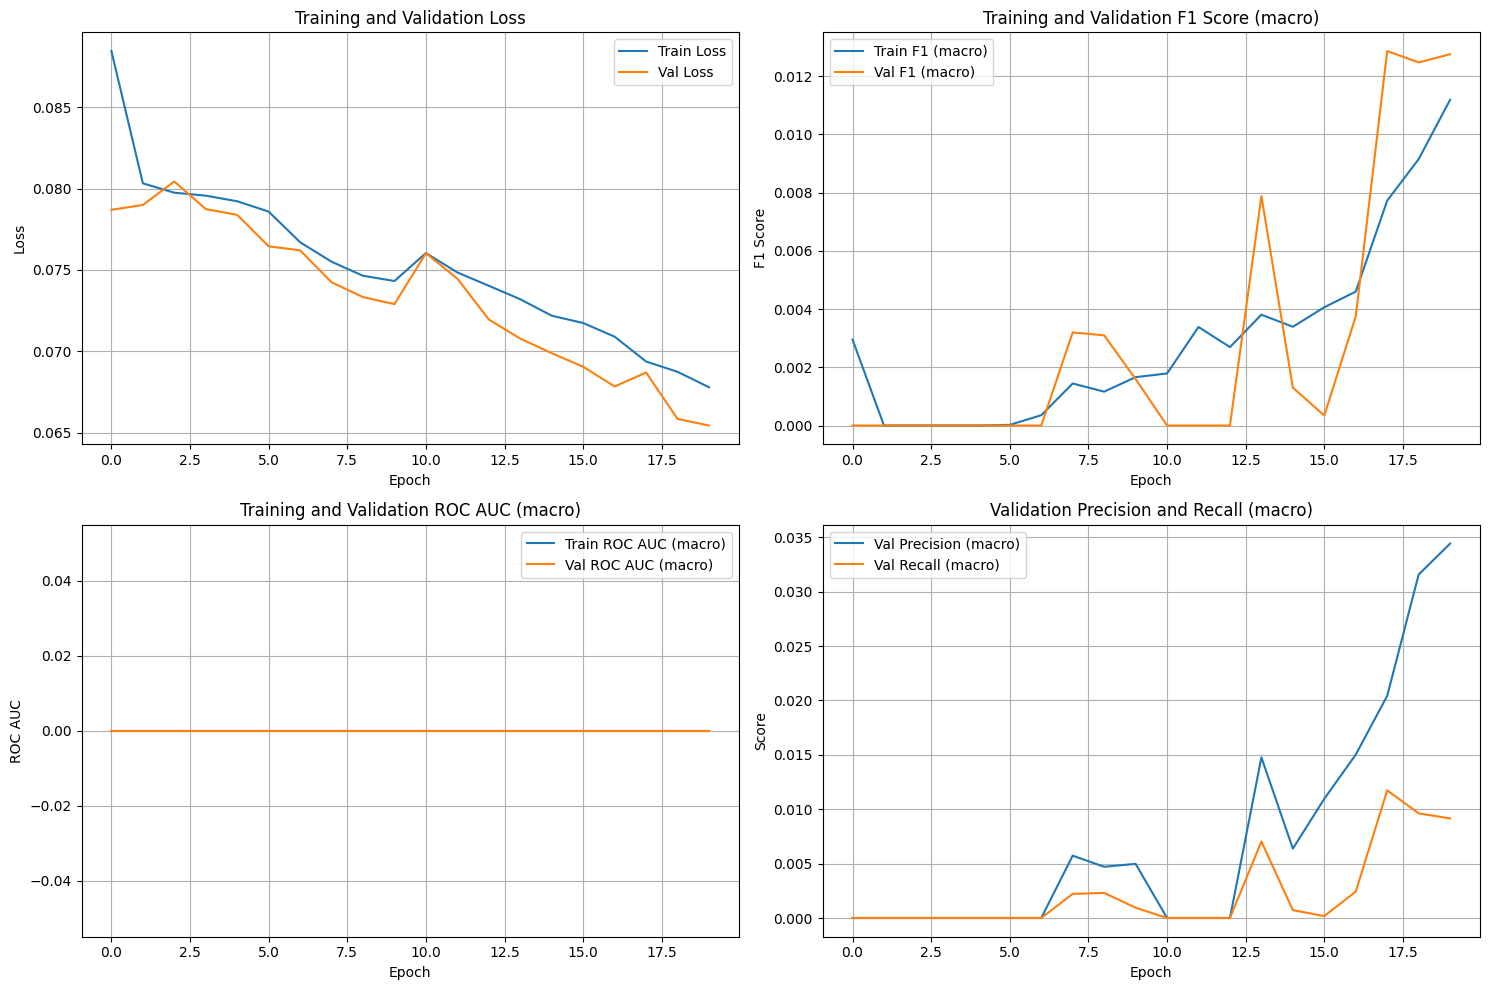

Training visualization completed!


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get metrics history
metrics_summary = trainer.metrics_tracker.get_metrics_summary()

# Plot training curves
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss curves
if 'train' in metrics_summary and 'loss' in metrics_summary['train']:
    train_loss = trainer.metrics_tracker.metrics_history['train']['loss']
    val_loss = trainer.metrics_tracker.metrics_history['val']['loss']
    
    axes[0, 0].plot(train_loss, label='Train Loss')
    axes[0, 0].plot(val_loss, label='Val Loss')
    axes[0, 0].set_title('Training and Validation Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True)

# F1 Score curves
if 'train' in metrics_summary and 'f1_macro' in metrics_summary['train']:
    train_f1 = trainer.metrics_tracker.metrics_history['train']['f1_macro']
    val_f1 = trainer.metrics_tracker.metrics_history['val']['f1_macro']
    
    axes[0, 1].plot(train_f1, label='Train F1 (macro)')
    axes[0, 1].plot(val_f1, label='Val F1 (macro)')
    axes[0, 1].set_title('Training and Validation F1 Score (macro)')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('F1 Score')
    axes[0, 1].legend()
    axes[0, 1].grid(True)

# ROC AUC curves
if 'train' in metrics_summary and 'roc_auc_macro' in metrics_summary['train']:
    train_auc = trainer.metrics_tracker.metrics_history['train']['roc_auc_macro']
    val_auc = trainer.metrics_tracker.metrics_history['val']['roc_auc_macro']
    
    axes[1, 0].plot(train_auc, label='Train ROC AUC (macro)')
    axes[1, 0].plot(val_auc, label='Val ROC AUC (macro)')
    axes[1, 0].set_title('Training and Validation ROC AUC (macro)')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('ROC AUC')
    axes[1, 0].legend()
    axes[1, 0].grid(True)

# Precision and Recall
if 'val' in metrics_summary and 'precision_macro' in metrics_summary['val']:
    val_precision = trainer.metrics_tracker.metrics_history['val']['precision_macro']
    val_recall = trainer.metrics_tracker.metrics_history['val']['recall_macro']
    
    axes[1, 1].plot(val_precision, label='Val Precision (macro)')
    axes[1, 1].plot(val_recall, label='Val Recall (macro)')
    axes[1, 1].set_title('Validation Precision and Recall (macro)')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Score')
    axes[1, 1].legend()
    axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

print("Training visualization completed!")

## 7. Test Model on Sample Audio Files

In [12]:
import nbformat
from nbconvert import PythonExporter

# Convert notebook to python script
with open('audio_data_pipeline.ipynb', encoding='utf-8') as f:
    nb = nbformat.read(f, as_version=4)

exporter = PythonExporter()
source, _ = exporter.from_notebook_node(nb)

with open('audio_data_pipeline.py', 'w', encoding='utf-8') as f:
    f.write(source)

print("audio_data_pipeline.py created successfully!")

audio_data_pipeline.py created successfully!


In [13]:
# Import inference utilities
from training.inference import AudioGenrePredictor

# Initialize predictor with the best model
predictor = AudioGenrePredictor(best_model_path, config_path=None, device=str(DEVICE))

# Test on a few sample audio files
sample_audio_files = []
for i, path in enumerate(train_dataset.audio_paths[:5]):
    if os.path.exists(path):
        sample_audio_files.append(str(path))

print(f"Testing on {len(sample_audio_files)} sample audio files...")

for audio_path in sample_audio_files:
    try:
        result = predictor.predict(audio_path, return_probabilities=True)
        print(f"\nFile: {os.path.basename(audio_path)}")
        print(f"Predicted genres: {result['predicted_indices']}")
        print(f"Probabilities: {result['predicted_probabilities'][:5]}...")  # Show first 5
        print(f"Number of predicted genres: {len(result['predicted_indices'])}")
    except Exception as e:
        print(f"Error processing {audio_path}: {e}")

print("\nInference testing completed!")

Python      : 3.10.9
NumPy       : 2.2.6
Pandas      : 2.3.1
Librosa     : 0.11.0
PyTorch     : 2.7.1+cu118
Scikit-learn: 1.7.1

Resampler   : soxr found  → will use res_type='soxr_hq'

CUDA available  : True
CUDA version    : 11.8
GPU [0]          : NVIDIA GeForce RTX 3050 Laptop GPU  |  4.0 GB VRAM

Active device   : cuda
Using resampler: soxr_hq
Config: {'audio_dir': 'fma_small', 'metadata_csv': 'fma_metadata/tracks.csv', 'subset': 'small', 'sr': 22050, 'segment_sec': 3, 'n_fft': 2048, 'hop_length': 512, 'n_mels': 128, 'test_size': 0.2, 'random_state': 42, 'batch_size': 16, 'num_workers': 0}
Tracks with genre labels : 8000
Unique genres            : 114
Label matrix shape       : (8000, 114)


Checking audio files: 100%|██████████| 8000/8000 [00:00<00:00, 31315.24file/s]



Files found    : 8000 / 8000
Files missing  : 0
Running smoke test on first 5 tracks...


Smoke test:  20%|██        | 1/5 [00:00<00:00,  8.84track/s]

  [0]  specs: (10, 1, 128, 130)   label: (114,)   NaN in specs: False


...

  [WARN] Could not load fma_small\098\098565.mp3: 


Train dry-run:  93%|█████████▎| 372/400 [10:26<00:47,  1.70s/batch]

  [WARN] Could not load fma_small\108\108925.mp3: 


Train dry-run: 100%|██████████| 400/400 [11:12<00:00,  1.68s/batch]



All batches clean — no NaN / Inf detected.
Last batch — specs: torch.Size([16, 10, 1, 128, 130])  labels: torch.Size([16, 114])
Top-20 genre frequencies in the dataset:
2       1000
10      1000
21      1000
12      1000
15      1000
17      1000
38      1000
1235    1000
18       685
76       403
103      373
25       366
182      298
107      249
79       229
539      223
66       219
468      218
85       215
1        212
Model loaded successfully from checkpoints\best.pth
Device: cuda
Number of classes: 114
Testing on 5 sample audio files...

File: 038779.mp3
Predicted genres: []
Probabilities: []...
Number of predicted genres: 0

File: 119941.mp3
Predicted genres: []
Probabilities: []...
Number of predicted genres: 0

File: 118958.mp3
Predicted genres: []
Probabilities: []...
Number of predicted genres: 0

File: 040239.mp3
Predicted genres: []
Probabilities: []...
Number of predicted genres: 0

File: 133272.mp3
Predicted genres: [4]
Probabilities: [0.7110432982444763]...
Number o

## 8. Save Final Results

In [14]:
# Save final configuration and results
results = {
    'final_config': config,
    'final_metrics': val_metrics,
    'best_f1_macro': best_f1,
    'best_epoch': best_epoch,
    'model_parameters': sum(p.numel() for p in trainer.model.parameters()),
    'training_completed': True
}

# Save results to JSON file
results_path = os.path.join(config['log_dir'], 'final_results.json')
with open(results_path, 'w') as f:
    json.dump(results, f, indent=2)

print(f"Final results saved to {results_path}")
print("\nTraining pipeline completed successfully!")
print(f"Best validation F1 (macro): {best_f1:.4f}")
print(f"Achieved at epoch: {best_epoch + 1}")
print(f"Model saved to: {config['checkpoint_dir']}/best.pth")
print(f"Logs saved to: {config['log_dir']}/")

Final results saved to logs\final_results.json

Training pipeline completed successfully!
Best validation F1 (macro): 0.0129
Achieved at epoch: 18
Model saved to: checkpoints/best.pth
Logs saved to: logs/
